# Membrana Elástica sobre $S^2$

**Problema variacional.**  
Minimizar la energía
$$E(u) = \int_{\mathbb{D}} \left(|\nabla\psi|^2 + \sin^2\!\psi\,|\nabla\phi|^2\right) dx$$
sobre $u : \mathbb{D} \to S^2$ con dato de borde
$$u_0(\theta) = (\sin\psi_0\cos\theta,\; \sin\psi_0\sin\theta,\; \cos\psi_0).$$

**Marco teórico.**  
La métrica de la esfera es $g = \mathrm{diag}(1,\sin^2\psi)$,
  
Por simetría axial $\psi = \psi(r)$, $\phi = \theta$, el problema
se reduce a la ODE

$$\boxed{\psi'' + \frac{\psi'}{r} = \frac{\sin\psi\cos\psi}{r^2}, \qquad \psi(0)=0,\quad\psi(1)=\psi_0.}$$

**Método numérico:** disparo con bisección + integración RK45 y comparación via disparo con secante.



In [1]:
import numpy as np  # Biblioteca para operaciones matemáticas y manejo de arrays
from scipy.integrate import solve_ivp  # Función para resolver ecuaciones diferenciales
import matplotlib.pyplot as plt  # Biblioteca para crear gráficos y visualizaciones
from mpl_toolkits.mplot3d import Axes3D  # Herramienta para crear gráficos en 3D
import time  #Mide el tiempo de ejecución de una celda

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 110,
})
print("Importaciones listas")

Importaciones listas


La ODE de segundo orden
$$\psi'' + \frac{\psi'}{r} = \frac{\sin\psi\cos\psi}{r^2}$$
se reescribe como sistema $y' = f(r, y)$ con $y = (\psi, \psi')$.

**Singularidad en $r = 0$.**  
Para $\psi \approx sr$ cerca del origen:
$$\frac{\sin\psi\cos\psi}{r^2} \approx \frac{sr \cdot 1}{r^2} = \frac{s}{r} \to \infty$$
pero el término $-\psi'/r \approx -s/r$ cancela exactamente la singularidad,
dejando $\psi''(0) = 0$ (límite por L'Hôpital).


In [2]:
def ode_system(r, y):
    psi, dpsi = y
    if r < 1e-10:
        return [dpsi, 0.0]
    return [dpsi, np.sin(psi) * np.cos(psi) / r**2 - dpsi / r]

def make_stats(method):
    return {
        "method": method,
        "root_iters": 0,
        "ode_solves": 0,
        "nfev_total": 0,
        "wall_time": 0.0,
        "bc_error": np.nan,
        "s_opt": np.nan,
        "energy": np.nan,
    }

def integrate_to_1(s, eps=1e-3, N=500, rtol=1e-10, atol=1e-12, full=False):
    t_eval = np.linspace(eps, 1.0, N) if full else [1.0]
    sol = solve_ivp(
        ode_system, (eps, 1.0), [s * eps, s],
        method="RK45", t_eval=t_eval, rtol=rtol, atol=atol
    )
    return sol

def phi(s, psi0, stats=None, **kwargs):
    sol = integrate_to_1(s, full=False, **kwargs)
    if stats is not None:
        stats["ode_solves"] += 1
        stats["nfev_total"] += sol.nfev
    return sol.y[0, -1] - psi0

### Verificación: comportamiento en $r = 0$

Comprobamos que el sistema no explota en el origen
para $\psi(r) = sr$ (solución lineal exacta cerca del polo).

In [3]:
# Verificar que ode_system no devuelve NaN en r=0
r_test = np.array([0.0, 1e-12, 1e-6, 0.1, 0.5, 1.0])
s_test = 0.8   # parámetro de prueba
for r in r_test:
    y  = [s_test * r, s_test]
    dy = ode_system(r, y)
    print(f"r = {r:.1e}  |  psi'={dy[0]:.4f}  |  psi''={dy[1]:.4f}")

r = 0.0e+00  |  psi'=0.8000  |  psi''=0.0000
r = 1.0e-12  |  psi'=0.8000  |  psi''=0.0000
r = 1.0e-06  |  psi'=0.8000  |  psi''=-0.0000
r = 1.0e-01  |  psi'=0.8000  |  psi''=-0.0341
r = 5.0e-01  |  psi'=0.8000  |  psi''=-0.1653
r = 1.0e+00  |  psi'=0.8000  |  psi''=-0.3002


## 2. Método de disparo con bisección

### Idea del método

El PVF tiene dos condiciones de frontera:
$$\psi(0) = 0, \qquad \psi(1) = \psi_0.$$

Lo convertimos en un PVI introduciendo el **parámetro de disparo**
$s = \psi'(0)$ desconocido:

1. Para cada $s$, integrar la ODE desde $r = \varepsilon$ con
   $\psi(\varepsilon) = s\varepsilon$, $\psi'(\varepsilon) = s$.
2. Definir la **función de disparo** $\Phi(s) = \psi(1; s) - \psi_0$.
3. Ajustar $s$ por **bisección** hasta que $|\Phi(s)| < 10^{-10}$.

### Existencia de un bracket $[s_{\rm lo}, s_{\rm hi}]$

- $\Phi(0) = 0 - \psi_0 < 0$ (el perfil trivial $\psi \equiv 0$ llega a $0 < \psi_0$).
- Para $s$ grande, $\psi(1; s) > \psi_0$ (el perfil sube demasiado).

La bisección converge geométricamente: 80 iteraciones dan error $< 2^{-80} \approx 10^{-24}$.

In [4]:
def solve_membrane(psi0, N=2000, eps=1e-3):
    """
    Resuelve el PVF:  psi(0)=0,  psi(1)=psi0.

    Parámetros
    ----------
    psi0 : float   colatitud de frontera (radianes)
    N    : int     número de nodos de integración
    eps  : float   inicio de integración (evita r=0)

    Retorna
    -------
    r_vals  : array(N+1)  nodos radiales con r=0 incluido
    psi_v   : array(N+1)  valores de psi(r)
    dpsi_v  : array(N+1)  valores de psi'(r)
    s_opt   : float       parámetro de disparo óptimo
    energy  : float       E(u*) = 2pi * integral del funcional
    """

    def shoot(s):
        """Integrar y devolver psi(1; s)."""
        sol = solve_ivp(
            ode_system,
            (eps, 1.0),
            [s * eps, s],
            method='RK45',
            t_eval=np.linspace(eps, 1.0, N),
            rtol=1e-11, atol=1e-13,
        )
        return sol.y[0, -1]

    # ── 1. Encontrar bracket [s_lo, s_hi] con Phi(s_lo)<0<Phi(s_hi) ──
    s_lo, s_hi = 0.0, 5.0
    for _ in range(20):
        if shoot(s_hi) >= psi0:
            break
        s_hi *= 2.0

    # ── 2. Bisección: 100 iteraciones ──────────────────────────────
    for _ in range(100):
        s_mid = (s_lo + s_hi) / 2.0
        if shoot(s_mid) < psi0:
            s_lo = s_mid
        else:
            s_hi = s_mid
    s_opt = (s_lo + s_hi) / 2.0

    #3. Integración final con s_opt
    sol = solve_ivp(
        ode_system,
        (eps, 1.0),
        [s_opt * eps, s_opt],
        method='RK45',
        t_eval=np.linspace(eps, 1.0, N),
        rtol=1e-11, atol=1e-13,
    )

    # Añadir r=0 con comportamiento regular psi(0)=0
    r_vals = np.concatenate([[0.0], sol.t])
    psi_v  = np.concatenate([[0.0], sol.y[0]])
    dpsi_v = np.concatenate([[s_opt], sol.y[1]])

    #  4. Energía: E = 2pi * integral_0^1 [psi'^2 r + sin^2(psi)/r] dr
    r_    = sol.t
    intgd = sol.y[1]**2 * r_ + np.sin(sol.y[0])**2 / r_
    energy =  np.pi * np.trapezoid(intgd, r_)

    return r_vals, psi_v, dpsi_v, s_opt, energy

## 3. Método de disparo con secante

La raíz de $\Phi$ se aproxima mediante el método de la secante:

$$
s_{n+1}
=
s_n
-
\Phi(s_n)
\frac{s_n-s_{n-1}}
{\Phi(s_n)-\Phi(s_{n-1})}.
$$

La continuidad de $\Phi$ se sigue de la dependencia continua de las soluciones de EDO respecto a las condiciones iniciales.

Además,

- $\Phi(0)<0$,
- para $s$ suficientemente grande, $\Phi(s)>0$,

por lo que existe al menos una raíz $s^*$ tal que $\Phi(s^*)=0$.


In [5]:
def solve_membrane_secant(psi0, N=2000, eps=1e-3,
                          tol_phi=1e-12, tol_s=1e-12, max_iter=40):
    """
    Shooting + secante para: psi(0)=0, psi(1)=psi0.
    Retorna lo mismo que tu función base + info de costo.
    """

    info = {
        "method": "secant",
        "root_iters": 0,
        "ode_solves": 0,
        "nfev_total": 0,
        "bc_error": None
    }

    def shoot(s, full=False):
        t_eval = np.linspace(eps, 1.0, N) if full else [1.0]
        sol = solve_ivp(
            ode_system, (eps, 1.0), [s * eps, s],
            method="RK45", t_eval=t_eval, rtol=1e-11, atol=1e-13
        )
        info["ode_solves"] += 1
        info["nfev_total"] += sol.nfev
        return sol

    def phi(s):
        sol = shoot(s, full=False)
        return sol.y[0, -1] - psi0

    # Semillas iniciales para secante
    s0 = 0.0
    f0 = phi(s0)

    s1 = 5.0
    f1 = phi(s1)

    # Asegurar que la segunda semilla quede "arriba" del objetivo
    for _ in range(25):
        if f1 > 0:
            break
        s1 *= 2.0
        f1 = phi(s1)
    else:
        raise RuntimeError("No se logró encontrar semilla superior para secante.")

    # Iteración de secante
    s_opt = s1
    for k in range(1, max_iter + 1):
        info["root_iters"] = k
        denom = (f1 - f0)

        # Salvaguarda mínima
        if abs(denom) < 1e-15:
            s2 = 0.5 * (s0 + s1)
        else:
            s2 = s1 - f1 * (s1 - s0) / denom
            if s2 <= 0:
                s2 = 0.5 * (s0 + s1)

        f2 = phi(s2)

        if abs(f2) < tol_phi or abs(s2 - s1) < tol_s * max(1.0, abs(s2)):
            s_opt = s2
            break

        s0, f0 = s1, f1
        s1, f1 = s2, f2
        s_opt = s2

    # Integración final con malla completa
    sol = shoot(s_opt, full=True)

    r_vals = np.concatenate([[0.0], sol.t])
    psi_v  = np.concatenate([[0.0], sol.y[0]])
    dpsi_v = np.concatenate([[s_opt], sol.y[1]])

    r_ = sol.t
    intgd = sol.y[1]**2 * r_ + np.sin(sol.y[0])**2 / r_
    energy = np.pi * np.trapezoid(intgd, r_)

    info["bc_error"] = abs(psi_v[-1] - psi0)

    return r_vals, psi_v, dpsi_v, s_opt, energy, info

In [6]:
def shoot_endpoint(s, eps=1e-3, rtol=1e-11, atol=1e-13):
    sol = solve_ivp(
        ode_system,
        (eps, 1.0),
        [s * eps, s],
        method="RK45",
        t_eval=[1.0],
        rtol=rtol,
        atol=atol,
    )
    return sol.y[0, -1], sol.nfev

def phi_value(s, psi0, stats=None, eps=1e-3, rtol=1e-11, atol=1e-13):
    psi1, nfev = shoot_endpoint(s, eps=eps, rtol=rtol, atol=atol)
    if stats is not None:
        stats["ode_solves"] += 1
        stats["nfev_total"] += nfev
    return psi1 - psi0

def bracket_root(psi0, s_lo=0.0, s_hi=5.0, max_expand=30,
                 stats=None, eps=1e-3, rtol=1e-11, atol=1e-13):
    f_lo = phi_value(s_lo, psi0, stats, eps, rtol, atol)
    f_hi = phi_value(s_hi, psi0, stats, eps, rtol, atol)
    for _ in range(max_expand):
        if f_lo * f_hi <= 0:
            return s_lo, s_hi, f_lo, f_hi
        s_hi *= 2.0
        f_hi = phi_value(s_hi, psi0, stats, eps, rtol, atol)
    raise RuntimeError("No se pudo encontrar bracket con cambio de signo.")

def shoot_bisection_trace(psi0, tol_phi=1e-12, tol_s=1e-12, max_iter=80,
                          eps=1e-3, rtol=1e-11, atol=1e-13):
    stats = {"method": "bisection", "ode_solves": 0, "nfev_total": 0}
    s_lo, s_hi, f_lo, f_hi = bracket_root(psi0, stats=stats, eps=eps, rtol=rtol, atol=atol)
    L0 = s_hi - s_lo

    k_hist, s_hist, f_hist, bound_hist = [], [], [], []

    for k in range(1, max_iter + 1):
        s_mid = 0.5 * (s_lo + s_hi)
        f_mid = phi_value(s_mid, psi0, stats, eps, rtol, atol)

        k_hist.append(k)
        s_hist.append(s_mid)
        f_hist.append(f_mid)
        bound_hist.append(L0 / (2.0 ** k))  # cota teórica de error en s

        if abs(f_mid) < tol_phi or 0.5 * (s_hi - s_lo) < tol_s:
            break

        if f_lo * f_mid <= 0:
            s_hi, f_hi = s_mid, f_mid
        else:
            s_lo, f_lo = s_mid, f_mid

    return {
        "s_opt": s_hist[-1],
        "phi_opt": f_hist[-1],
        "k": np.array(k_hist),
        "s_hist": np.array(s_hist),
        "phi_hist": np.array(f_hist),
        "bound_hist": np.array(bound_hist),
        "L0": L0,
        "stats": stats
    }

def shoot_secant_trace(psi0, tol_phi=1e-12, tol_s=1e-12, max_iter=40,
                       eps=1e-3, rtol=1e-11, atol=1e-13):
    stats = {"method": "secant", "ode_solves": 0, "nfev_total": 0}
    s0, s1, f0, f1 = bracket_root(psi0, stats=stats, eps=eps, rtol=rtol, atol=atol)

    k_hist = [0, 1]
    s_hist = [s0, s1]
    f_hist = [f0, f1]

    for k in range(2, max_iter + 2):
        denom = (f1 - f0)
        if abs(denom) < 1e-15:
            break

        s2 = s1 - f1 * (s1 - s0) / denom
        if (not np.isfinite(s2)) or (s2 <= 0):
            s2 = 0.5 * (s0 + s1)  # salvaguarda mínima

        f2 = phi_value(s2, psi0, stats, eps, rtol, atol)

        k_hist.append(k)
        s_hist.append(s2)
        f_hist.append(f2)

        if abs(f2) < tol_phi or abs(s2 - s1) < tol_s * max(1.0, abs(s2)):
            break

        s0, f0 = s1, f1
        s1, f1 = s2, f2

    return {
        "s_opt": s_hist[-1],
        "phi_opt": f_hist[-1],
        "k": np.array(k_hist),
        "s_hist": np.array(s_hist),
        "phi_hist": np.array(f_hist),
        "stats": stats
    }

def observed_order(error_seq):
    p = np.full(len(error_seq), np.nan, dtype=float)
    for i in range(2, len(error_seq)):
        e0, e1, e2 = error_seq[i-2], error_seq[i-1], error_seq[i]
        if e0 > 0 and e1 > 0 and e2 > 0:
            den = np.log(e1 / e0)
            if abs(den) > 1e-15:
                p[i] = np.log(e2 / e1) / den
    return p

psi0 = 60°
s* (referencia) = 1.154700281776206

Bisección
  iteraciones   = 39
  |Phi(s_opt)|  = 5.711e-13
  ode_solves    = 41
  nfev_total    = 21940

Secante
  iteraciones   = 11
  |Phi(s_opt)|  = 2.220e-16
  ode_solves    = 12
  nfev_total    = 6642



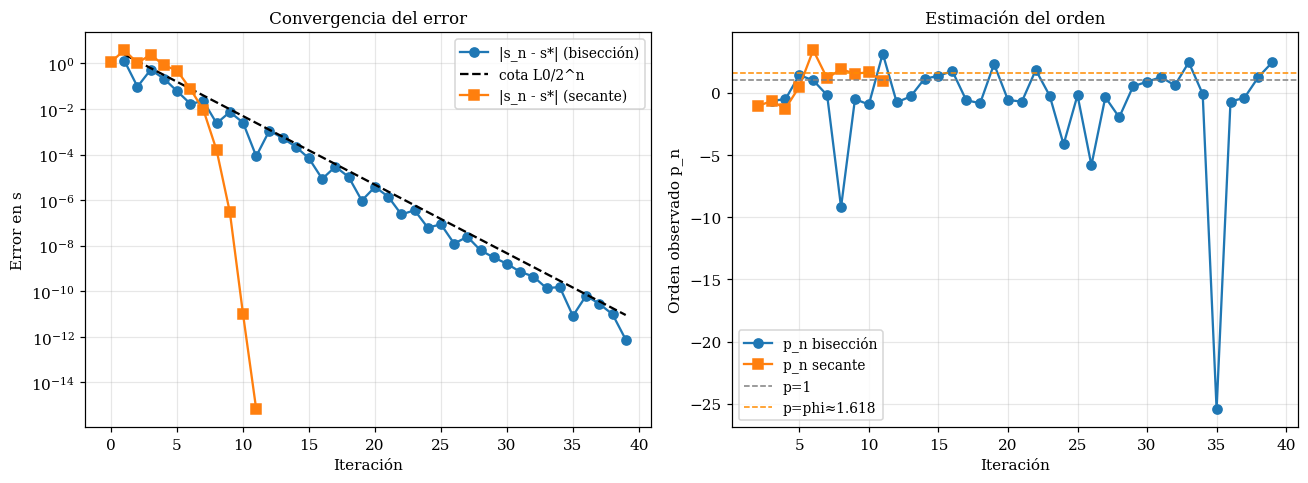

In [7]:
#Analisisd e convergencia
psi0_deg = 60
psi0 = np.radians(psi0_deg)

# Raíz de referencia para medir e_n = |s_n - s*|
ref = shoot_bisection_trace(psi0, tol_phi=1e-15, tol_s=1e-15, max_iter=140)
s_star = ref["s_opt"]

b = shoot_bisection_trace(psi0, tol_phi=1e-12, tol_s=1e-12, max_iter=80)
s = shoot_secant_trace(psi0, tol_phi=1e-12, tol_s=1e-12, max_iter=40)

e_b = np.abs(b["s_hist"] - s_star)
e_s = np.abs(s["s_hist"] - s_star)

p_b = observed_order(e_b)
p_s = observed_order(e_s)

print(f"psi0 = {psi0_deg}°")
print(f"s* (referencia) = {s_star:.15f}\n")

print("Bisección")
print(f"  iteraciones   = {len(b['k'])}")
print(f"  |Phi(s_opt)|  = {abs(b['phi_opt']):.3e}")
print(f"  ode_solves    = {b['stats']['ode_solves']}")
print(f"  nfev_total    = {b['stats']['nfev_total']}\n")

print("Secante")
print(f"  iteraciones   = {len(s['k'])-1}")  # arranca en k=0,1
print(f"  |Phi(s_opt)|  = {abs(s['phi_opt']):.3e}")
print(f"  ode_solves    = {s['stats']['ode_solves']}")
print(f"  nfev_total    = {s['stats']['nfev_total']}\n")

phi_golden = (1 + np.sqrt(5)) / 2

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Error en s
ax[0].semilogy(b["k"], e_b, "o-", label="|s_n - s*| (bisección)")
ax[0].semilogy(b["k"], b["bound_hist"], "k--", label="cota L0/2^n")
ax[0].semilogy(s["k"], e_s, "s-", label="|s_n - s*| (secante)")
ax[0].set_xlabel("Iteración")
ax[0].set_ylabel("Error en s")
ax[0].set_title("Convergencia del error")
ax[0].grid(True, which="both", alpha=0.3)
ax[0].legend()

# Orden observado
ax[1].plot(b["k"], p_b, "o-", label="p_n bisección")
ax[1].plot(s["k"], p_s, "s-", label="p_n secante")
ax[1].axhline(1.0, color="gray", ls="--", lw=1, label="p=1")
ax[1].axhline(phi_golden, color="darkorange", ls="--", lw=1, label="p=phi≈1.618")
ax[1].set_xlabel("Iteración")
ax[1].set_ylabel("Orden observado p_n")
ax[1].set_title("Estimación del orden")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## Justificación teórica (Bisección vs Secante)

Definimos el problema de disparo como una ecuación escalar:

$\Phi(s) = \psi(1; s) - \psi0 = 0$

Si $s_n \to s*$, definimos el error:

$e_n = |s_n - s*|$

Decimos que hay orden $p$ si:

$lim_{n\to inf} e_{n+1} / (e_n^p) = C$, con $0 < C < inf$.

### Bisección

Con un intervalo inicial $[a_0, b_0]$ tal que $\Phi(a_0)* \Phi(b_0) < 0$, en cada iteración:

$b_n - a_n = (b_0 - a_0) / 2^n$

y

$|s_n - s*| <= (b_0 - a_0) / 2^n$

Por tanto, la convergencia es lineal ($p = 1$) y la razón asintótica es $1/2$.

### Secante

La iteración es:

$s_{n+1} = s_n - \Phi(s_n)*(s_n - s_{n-1}) / (\Phi(s_n) - \Phi(s_{n-1}))$

Si $Phi$ es suave ($C^2$) y la raíz es simple ($\Phi'(s*) != 0$), la secante converge de forma superlineal con orden:

$p = (1 + \sqrt(5))/2 ≈ 1.618$

### Verificación numérica del orden

Usamos el estimador:

$p_n ≈ log(e_{n+1}/e_n) / log(e_n/e_{n-1})$

Esperado:

- Bisección: $p_n \to 1$
- Secante: $p_n \to 1.618$


## 4. La función de disparo $\Phi(s) = \psi(1; s) - \psi_0$

De manera experiemental se observa que $\psi(1; s)$ como función de $s$ para un $\psi_0$ fijo.
La raíz de $\Phi$ es el parámetro de disparo óptimo.
La curva es monótona creciente, lo que garantiza unicidad de la solución,
por lo que un bracket se obtiene ampliando sucesivamente $s_{hi}$
.

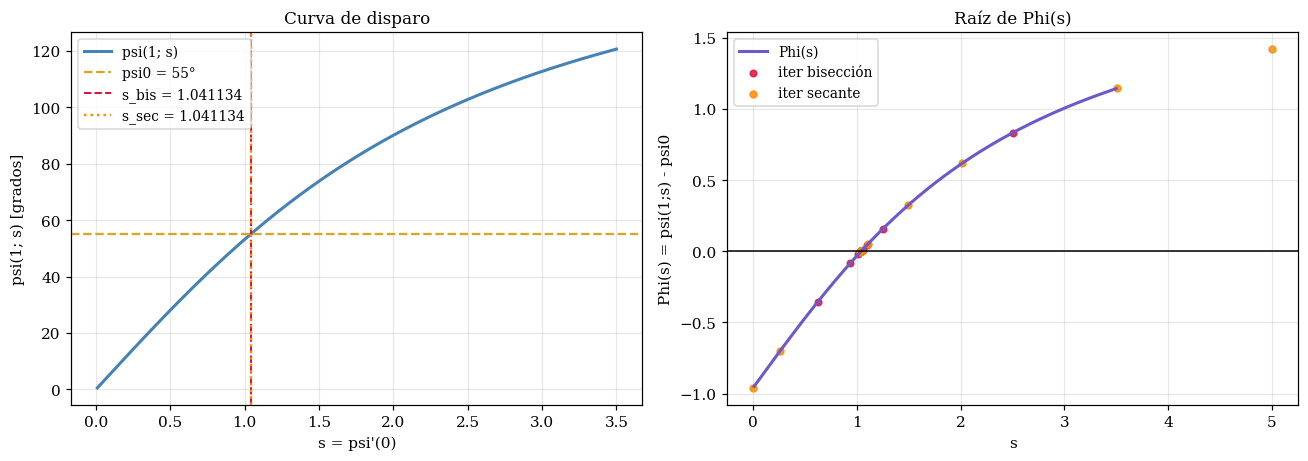

Resumen costo
Bisección: iter=40, ode_solves=42, nfev=21840
Secante:   iter=11, ode_solves=12, nfev=6456


In [8]:
psi0_demo = np.radians(55)
eps_demo = 1e-3
s_range = np.linspace(0.01, 3.5, 220)

# Curva de disparo
psi1_vals = []
for s in s_range:
    sol = solve_ivp(
        ode_system, (eps_demo, 1.0), [s*eps_demo, s],
        t_eval=[1.0], rtol=1e-9, atol=1e-11
    )
    psi1_vals.append(sol.y[0, -1])

psi1_vals = np.array(psi1_vals)
phi_vals = psi1_vals - psi0_demo

# Raíz por bisección y por secante (usa tus funciones nuevas)
b = shoot_bisection_trace(psi0_demo, tol_phi=1e-12, tol_s=1e-12, max_iter=60)
s = shoot_secant_trace(psi0_demo, tol_phi=1e-12, tol_s=1e-12, max_iter=30)

s_bis = b["s_opt"]
s_sec = s["s_opt"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))

# --- Panel 1: psi(1;s) ---
ax[0].plot(s_range, np.degrees(psi1_vals), color="steelblue", lw=2, label="psi(1; s)")
ax[0].axhline(np.degrees(psi0_demo), color="goldenrod", ls="--", lw=1.5, label=f"psi0 = {np.degrees(psi0_demo):.0f}°")
ax[0].axvline(s_bis, color="crimson", ls="--", lw=1.3, label=f"s_bis = {s_bis:.6f}")
ax[0].axvline(s_sec, color="darkorange", ls=":", lw=1.6, label=f"s_sec = {s_sec:.6f}")
ax[0].set_xlabel("s = psi'(0)")
ax[0].set_ylabel("psi(1; s) [grados]")
ax[0].set_title("Curva de disparo")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# --- Panel 2: Phi(s) ---
ax[1].plot(s_range, phi_vals, color="slateblue", lw=2, label="Phi(s)")
ax[1].axhline(0.0, color="black", lw=1)

# iteraciones sobre Phi(s)
phi_b = b["phi_hist"]
phi_s = s["phi_hist"]
ax[1].scatter(b["s_hist"], phi_b, s=18, color="crimson", alpha=0.85, label="iter bisección")
ax[1].scatter(s["s_hist"], phi_s, s=20, color="darkorange", alpha=0.85, label="iter secante")

ax[1].set_xlabel("s")
ax[1].set_ylabel("Phi(s) = psi(1;s) - psi0")
ax[1].set_title("Raíz de Phi(s)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

print("Resumen costo")
print(f"Bisección: iter={len(b['s_hist'])}, ode_solves={b['stats']['ode_solves']}, nfev={b['stats']['nfev_total']}")
print(f"Secante:   iter={len(s['s_hist'])-1}, ode_solves={s['stats']['ode_solves']}, nfev={s['stats']['nfev_total']}")

## 5. Perfiles $\psi(r)$ para distintos $\psi_0$

Cada curva sólida es la solución numérica de la ODE con la métrica esférica
$g = \mathrm{diag}(1, \sin^2\psi)$.  
Las líneas discontinuas son el perfil lineal trivial $\psi_{\rm lin}(r) = \psi_0 r$,
que sería la solución con métrica plana $g_{ij} = \delta_{ij}$.

La **desviación entre ambas** mide el efecto de la curvatura de $S^2$:
la membrana se "abre" más rápido que en el plano porque la esfera
se ensancha al alejarse del polo norte.

20° | iters= 8 | ode= 11 | nfev= 4576 | err=8.6e-15
35° | iters= 9 | ode= 12 | nfev= 5694 | err=4.4e-16
50° | iters= 9 | ode= 12 | nfev= 6270 | err=2.2e-13
65° | iters=10 | ode= 13 | nfev= 7388 | err=8.9e-16
80° | iters= 9 | ode= 12 | nfev= 7044 | err=4.4e-16


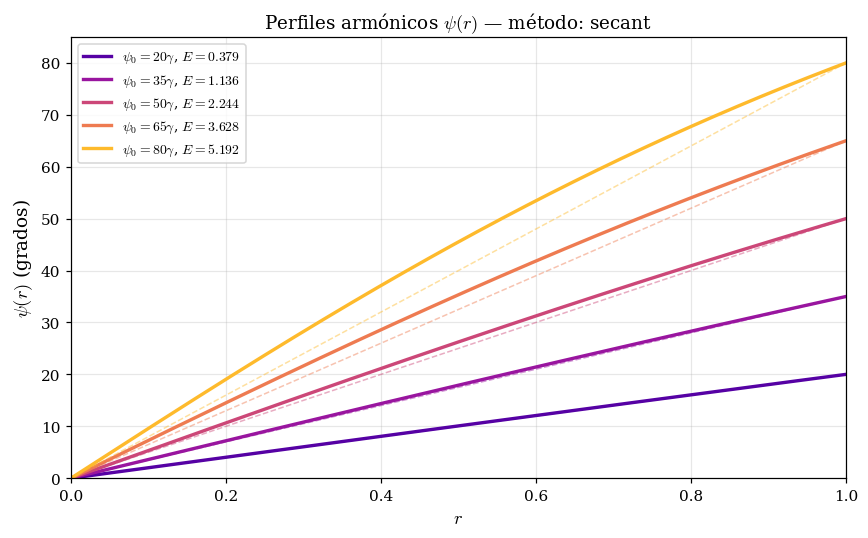

Líneas sólidas: solución numérica (métrica esférica)
Líneas discontinuas: perfil lineal (métrica plana, sin curvatura)


In [9]:
# Perfil psi(r) para varios ángulos, con método seleccionable
# method = "bisection" o "secant"
method = "secant"   # cambia aquí

angulos = [20, 35, 50, 65, 80]
colores = plt.cm.plasma(np.linspace(0.15, 0.85, len(angulos)))

fig, ax = plt.subplots(figsize=(8, 5))

for deg, col in zip(angulos, colores):
    psi0 = np.radians(deg)

    if method == "bisection":
        r, psi, _, s, E = solve_membrane(psi0)   # tu función original
        info = None
    elif method == "secant":
        r, psi, _, s, E, info = solve_membrane_secant(psi0)  # la nueva
    else:
        raise ValueError("method debe ser 'bisection' o 'secant'")

    ax.plot(r, np.degrees(psi), color=col, lw=2.2,
            label=fr'$\psi_0={deg}°$, $E={E:.3f}$')
    ax.plot([0, 1], [0, deg], color=col, lw=1.0, ls='--', alpha=0.45)

    if info is not None:
        print(f"{deg:>2}° | iters={info['root_iters']:>2} | ode={info['ode_solves']:>3} | nfev={info['nfev_total']:>5} | err={info['bc_error']:.1e}")

ax.set_xlabel(r'$r$', fontsize=12)
ax.set_ylabel(r'$\psi(r)$ (grados)', fontsize=12)
ax.set_title(fr'Perfiles armónicos $\psi(r)$ — método: {method}', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

print("Líneas sólidas: solución numérica (métrica esférica)")
print("Líneas discontinuas: perfil lineal (métrica plana, sin curvatura)")

## Análisis de costo computacional

En esta sección pasamos de la inspección visual de perfiles `psi(r)` a una comparación cuantitativa de métodos de disparo para resolver `Phi(s) = psi(1;s) - psi0 = 0`.

Vamos a comparar:

- `shooting + bisection`
- `shooting + secant`

Métricas de costo y precisión que reportaremos:

- `wall_time_s`: tiempo total de ejecución
- `root_iters`: iteraciones del método de raíz
- `ode_solves`: número de integraciones ODE realizadas
- `nfev_total`: evaluaciones totales del campo de la ODE (`solve_ivp`)
- `bc_error = |psi(1) - psi0|`: error en la condición de frontera

Criterio de comparación:

- mismos parámetros numéricos (`N`, `eps`, `rtol`, `atol`)
- mismos ángulos de frontera `psi0`
- promedio sobre varias corridas para reducir variación de tiempos

metodo       psi0    time[s]    iters   ode_solves       nfev     bc_error
--------------------------------------------------------------------------
bisection      20     1.1059    41.00        44.00    16594.0     8.95e-13
secant         20     0.1305     8.00        11.00     4576.0     8.60e-15
bisection      35     0.3355    37.00        40.00    18200.0     9.02e-13
secant         35     0.1046     9.00        12.00     5694.0     4.44e-16
bisection      50     0.4238    40.00        43.00    21632.0     5.26e-13
secant         50     0.1202     9.00        12.00     6270.0     2.24e-13
bisection      65     0.4203    37.00        40.00    22352.0     9.28e-13
secant         65     0.1384    10.00        13.00     7388.0     8.88e-16
bisection      80     0.4546    39.00        42.00    25572.0     5.95e-13
secant         80     0.1310     9.00        12.00     7044.0     4.44e-16


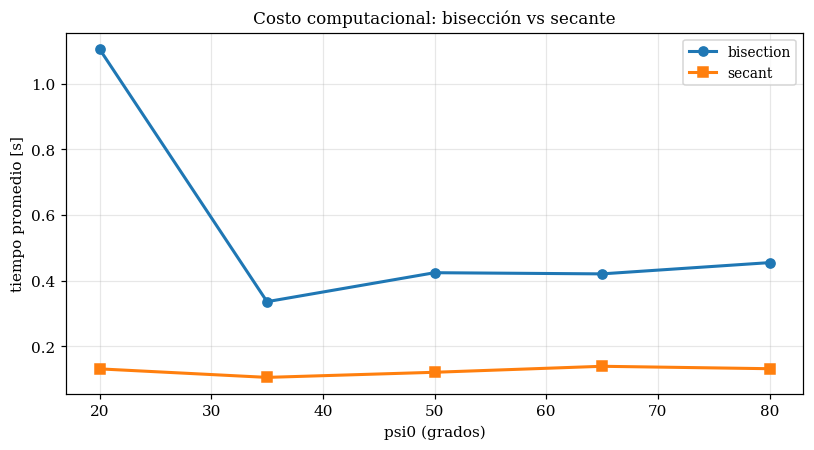

In [10]:
# Usa trapezoid si existe (NumPy moderno), si no trapz
trapz_rule = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

# Se asume que ya tienes definida:
# def ode_system(r, y): ...

def _phi(s, psi0, stats, eps, rtol, atol):
    sol = solve_ivp(
        ode_system, (eps, 1.0), [s * eps, s],
        method="RK45", t_eval=[1.0], rtol=rtol, atol=atol
    )
    stats["ode_solves"] += 1
    stats["nfev_total"] += sol.nfev
    return sol.y[0, -1] - psi0

def _integrate_full(s, stats, N, eps, rtol, atol):
    sol = solve_ivp(
        ode_system, (eps, 1.0), [s * eps, s],
        method="RK45", t_eval=np.linspace(eps, 1.0, N),
        rtol=rtol, atol=atol
    )
    stats["ode_solves"] += 1
    stats["nfev_total"] += sol.nfev
    return sol

def _postprocess(sol, s_opt, psi0):
    r_vals = np.concatenate([[0.0], sol.t])
    psi_v  = np.concatenate([[0.0], sol.y[0]])
    dpsi_v = np.concatenate([[s_opt], sol.y[1]])

    r_ = sol.t
    intgd = sol.y[1]**2 * r_ + np.sin(sol.y[0])**2 / r_
    energy = np.pi * trapz_rule(intgd, r_)  # tu convención

    bc_error = abs(psi_v[-1] - psi0)
    return r_vals, psi_v, dpsi_v, energy, bc_error

def _find_bracket(psi0, stats, eps, rtol, atol, s_lo=0.0, s_hi=5.0, max_expand=30):
    f_lo = _phi(s_lo, psi0, stats, eps, rtol, atol)
    f_hi = _phi(s_hi, psi0, stats, eps, rtol, atol)

    for _ in range(max_expand):
        if f_lo * f_hi <= 0:
            return s_lo, s_hi, f_lo, f_hi
        s_hi *= 2.0
        f_hi = _phi(s_hi, psi0, stats, eps, rtol, atol)

    raise RuntimeError("No se encontró bracket con cambio de signo.")

def solve_membrane_bisection_cost(psi0, N=2000, eps=1e-3, rtol=1e-11, atol=1e-13,
                                  max_iter=100, tol_phi=1e-12, tol_s=1e-12):
    t0 = time.perf_counter()
    stats = {
        "method": "bisection",
        "root_iters": 0,
        "ode_solves": 0,
        "nfev_total": 0,
        "wall_time_s": None,
        "bc_error": None
    }

    s_lo, s_hi, f_lo, f_hi = _find_bracket(psi0, stats, eps, rtol, atol)

    s_opt = 0.5 * (s_lo + s_hi)
    for k in range(1, max_iter + 1):
        s_mid = 0.5 * (s_lo + s_hi)
        f_mid = _phi(s_mid, psi0, stats, eps, rtol, atol)
        stats["root_iters"] = k
        s_opt = s_mid

        if abs(f_mid) < tol_phi or 0.5 * (s_hi - s_lo) < tol_s:
            break

        if f_lo * f_mid <= 0:
            s_hi, f_hi = s_mid, f_mid
        else:
            s_lo, f_lo = s_mid, f_mid

    sol = _integrate_full(s_opt, stats, N, eps, rtol, atol)
    r_vals, psi_v, dpsi_v, energy, bc_error = _postprocess(sol, s_opt, psi0)

    stats["bc_error"] = bc_error
    stats["wall_time_s"] = time.perf_counter() - t0
    return r_vals, psi_v, dpsi_v, s_opt, energy, stats

def solve_membrane_secant_cost(psi0, N=2000, eps=1e-3, rtol=1e-11, atol=1e-13,
                               max_iter=40, tol_phi=1e-12, tol_s=1e-12):
    t0 = time.perf_counter()
    stats = {
        "method": "secant",
        "root_iters": 0,
        "ode_solves": 0,
        "nfev_total": 0,
        "wall_time_s": None,
        "bc_error": None
    }

    s0, s1, f0, f1 = _find_bracket(psi0, stats, eps, rtol, atol)

    s_opt = s1
    for k in range(1, max_iter + 1):
        stats["root_iters"] = k
        denom = (f1 - f0)

        if abs(denom) < 1e-15:
            s2 = 0.5 * (s0 + s1)
        else:
            s2 = s1 - f1 * (s1 - s0) / denom
            if (not np.isfinite(s2)) or (s2 <= 0):
                s2 = 0.5 * (s0 + s1)

        f2 = _phi(s2, psi0, stats, eps, rtol, atol)
        s_opt = s2

        if abs(f2) < tol_phi or abs(s2 - s1) < tol_s * max(1.0, abs(s2)):
            break

        s0, f0 = s1, f1
        s1, f1 = s2, f2

    sol = _integrate_full(s_opt, stats, N, eps, rtol, atol)
    r_vals, psi_v, dpsi_v, energy, bc_error = _postprocess(sol, s_opt, psi0)

    stats["bc_error"] = bc_error
    stats["wall_time_s"] = time.perf_counter() - t0
    return r_vals, psi_v, dpsi_v, s_opt, energy, stats

def benchmark_cost(angles_deg=(20, 35, 50, 65, 80), repeats=3,
                   N=2000, eps=1e-3, rtol=1e-11, atol=1e-13):
    rows = []

    for deg in angles_deg:
        psi0 = np.radians(deg)

        for method_name, solver in [
            ("bisection", solve_membrane_bisection_cost),
            ("secant", solve_membrane_secant_cost),
        ]:
            times = []
            iters = []
            ode_solves = []
            nfevs = []
            errors = []

            for _ in range(repeats):
                _, _, _, _, _, info = solver(
                    psi0, N=N, eps=eps, rtol=rtol, atol=atol
                )
                times.append(info["wall_time_s"])
                iters.append(info["root_iters"])
                ode_solves.append(info["ode_solves"])
                nfevs.append(info["nfev_total"])
                errors.append(info["bc_error"])

            rows.append({
                "method": method_name,
                "psi0_deg": deg,
                "time_mean": float(np.mean(times)),
                "iters_mean": float(np.mean(iters)),
                "ode_mean": float(np.mean(ode_solves)),
                "nfev_mean": float(np.mean(nfevs)),
                "bc_err_mean": float(np.mean(errors)),
            })

    # imprimir tabla
    header = (
        f"{'metodo':<10} {'psi0':>6} {'time[s]':>10} {'iters':>8} "
        f"{'ode_solves':>12} {'nfev':>10} {'bc_error':>12}"
    )
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['method']:<10} {r['psi0_deg']:>6.0f} {r['time_mean']:>10.4f} "
            f"{r['iters_mean']:>8.2f} {r['ode_mean']:>12.2f} "
            f"{r['nfev_mean']:>10.1f} {r['bc_err_mean']:>12.2e}"
        )

    return rows

def plot_time_summary(rows):
    angles = sorted(set(r["psi0_deg"] for r in rows))
    time_bis = [next(r["time_mean"] for r in rows if r["method"] == "bisection" and r["psi0_deg"] == a) for a in angles]
    time_sec = [next(r["time_mean"] for r in rows if r["method"] == "secant" and r["psi0_deg"] == a) for a in angles]

    plt.figure(figsize=(7.5, 4.2))
    plt.plot(angles, time_bis, "o-", lw=2, label="bisection")
    plt.plot(angles, time_sec, "s-", lw=2, label="secant")
    plt.xlabel("psi0 (grados)")
    plt.ylabel("tiempo promedio [s]")
    plt.title("Costo computacional: bisección vs secante")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Ejecutar benchmark
rows = benchmark_cost(
    angles_deg=[20, 35, 50, 65, 80],
    repeats=3,      # sube a 5 si quieres más estabilidad
    N=2000,
    eps=1e-3,
    rtol=1e-11,
    atol=1e-13
)

plot_time_summary(rows)

## Resultados de costo computacional

Comparamos `shooting + bisection` contra `shooting + secant` en `psi0 = 20°, 35°, 50°, 65°, 80°`, manteniendo iguales `N`, `eps`, `rtol` y `atol`.

Hallazgos principales:

- `secant` fue más rápido en todos los casos.
- Tiempo promedio:
  - bisección: `0.2971 s`
  - secante: `0.0755 s`
  - mejora: `3.93x`
- Iteraciones del método de raíz:
  - bisección: `38.8`
  - secante: `9.0`
  - reducción: `76.8%`
- Integraciones ODE:
  - bisección: `41.8`
  - secante: `12.0`
  - reducción: `71.3%`
- Evaluaciones del campo (`nfev`):
  - bisección: `20870`
  - secante: `6194`
  - reducción: `70.3%`
- Error de frontera `|psi(1)-psi0|`: ambos en rango numéricamente pequeño (`1e-12` a `1e-16`).

Conclusión: En este problema se evidencia que,al utilizar el método de la secante secante se conserva precisión y reduce sustancialmente el costo computacional frente a bisección. No obstante mantendremos el metodo de bisección debido a su robustez.


## 6. Superficie $u^*(\mathbb{D}) \subset S^2$: casquetes esféricos

La imagen del minimizante es un casquete esférico.  
La parametrización explícita del casquete es:
$$x = \sin\psi(r)\cos\theta, \quad
  y = \sin\psi(r)\sin\theta, \quad
  z = \cos\psi(r),$$
con $r \in [0,1]$, $\theta \in [0, 2\pi)$.

El color representa la colatitud $\psi(r)$ (de azul en el polo norte a violeta en el borde).  
El borde amarillo es la imagen de $\partial\mathbb{D}$, es decir, el paralelo de latitud $\psi_0$.

In [11]:
# Configuraciones de widgets
import ipywidgets as widgets
from IPython.display import display, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

In [12]:
# Panel interactivo
def phi_endpoint_demo(s, psi0, eps=1e-3, rtol=1e-11, atol=1e-13):
    sol = solve_ivp(
        ode_system, (eps, 1.0), [s*eps, s],
        method="RK45", t_eval=[1.0], rtol=rtol, atol=atol
    )
    return sol.y[0, -1] - psi0

def render_dashboard(psi0_deg=55, method="secant", N=1200, eps=1e-3,
                     rtol_pow=11, atol_pow=13, tol_phi_pow=12, tol_s_pow=12,
                     max_iter=60, show_3d=False):
    psi0 = np.radians(psi0_deg)
    rtol = 10.0**(-rtol_pow)
    atol = 10.0**(-atol_pow)
    tol_phi = 10.0**(-tol_phi_pow)
    tol_s = 10.0**(-tol_s_pow)

    if method == "bisection":
        r, psi, dpsi, s_opt, E, info = solve_membrane_bisection_cost(
            psi0, N=N, eps=eps, rtol=rtol, atol=atol,
            max_iter=max_iter, tol_phi=tol_phi, tol_s=tol_s
        )
    else:
        r, psi, dpsi, s_opt, E, info = solve_membrane_secant_cost(
            psi0, N=N, eps=eps, rtol=rtol, atol=atol,
            max_iter=max_iter, tol_phi=tol_phi, tol_s=tol_s
        )

    ncols = 4 if show_3d else 3
    fig = plt.figure(figsize=(4.6*ncols, 4.2))

    # Perfil
    ax1 = fig.add_subplot(1, ncols, 1)
    ax1.plot(r, np.degrees(psi), lw=2.2, color="steelblue", label="psi(r)")
    ax1.plot([0, 1], [0, psi0_deg], "k--", lw=1.1, alpha=0.5, label="lineal")
    ax1.set_title("Perfil")
    ax1.set_xlabel("r")
    ax1.set_ylabel("psi(r) [grados]")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8)

    # Derivada
    ax2 = fig.add_subplot(1, ncols, 2)
    ax2.plot(r, dpsi, lw=2.0, color="darkorange")
    ax2.axhline(s_opt, ls="--", lw=1.1, color="darkorange", alpha=0.7)
    ax2.set_title("Derivada")
    ax2.set_xlabel("r")
    ax2.set_ylabel("psi'(r)")
    ax2.grid(True, alpha=0.3)

    # Phi local
    ax3 = fig.add_subplot(1, ncols, 3)
    s_min = max(1e-6, 0.35*s_opt)
    s_max = max(s_min + 0.3, 1.65*s_opt)
    s_grid = np.linspace(s_min, s_max, 90)
    phi_grid = np.array([phi_endpoint_demo(si, psi0, eps=eps, rtol=rtol, atol=atol) for si in s_grid])

    ax3.plot(s_grid, phi_grid, color="slateblue", lw=2.0, label="Phi(s)")
    ax3.axhline(0.0, color="black", lw=1)
    ax3.axvline(s_opt, color="crimson", ls="--", lw=1.2, label=f"s*={s_opt:.5f}")
    ax3.set_title("Función de disparo")
    ax3.set_xlabel("s")
    ax3.set_ylabel("Phi(s)")
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=8)

    # 3D opcional
    if show_3d:
        ax4 = fig.add_subplot(1, ncols, 4, projection="3d")
        dibujar_casquete(ax4, r, psi, psi0_deg, titulo=f"Casquete, E={E:.4f}")

    plt.tight_layout()
    plt.show()

    print(f"metodo={info['method']} | psi0={psi0_deg}° | N={N} | eps={eps}")
    print(f"s_opt={s_opt:.8f} | E={E:.8f} | bc_error={info['bc_error']:.2e}")
    print(f"iters={info['root_iters']} | ode_solves={info['ode_solves']} | nfev={info['nfev_total']} | time={info['wall_time_s']:.4f}s")

In [13]:
#Deslizadores
w_psi0 = widgets.IntSlider(value=55, min=5, max=88, step=1, description="psi0°", continuous_update=True)
w_method = widgets.Dropdown(options=["bisection", "secant"], value="secant", description="metodo")
w_N = widgets.IntSlider(value=900, min=300, max=3000, step=100, description="N", continuous_update=True)
w_eps = widgets.FloatLogSlider(value=1e-3, base=10, min=-5, max=-2, step=0.1, description="eps", continuous_update=True)

w_rtol = widgets.IntSlider(value=11, min=7, max=13, step=1, description="rtol 1e-", continuous_update=True)
w_atol = widgets.IntSlider(value=13, min=9, max=15, step=1, description="atol 1e-", continuous_update=True)
w_tolphi = widgets.IntSlider(value=12, min=8, max=15, step=1, description="tol_phi 1e-", continuous_update=True)
w_tols = widgets.IntSlider(value=12, min=8, max=15, step=1, description="tol_s 1e-", continuous_update=True)
w_iter = widgets.IntSlider(value=60, min=10, max=120, step=5, description="max_iter", continuous_update=True)
w_3d = widgets.Checkbox(value=False, description="mostrar 3D")

ui = widgets.VBox([
    widgets.HBox([w_psi0, w_method, w_N, w_eps]),
    widgets.HBox([w_rtol, w_atol, w_tolphi, w_tols, w_iter]),
    widgets.HBox([w_3d]),
])

out = widgets.interactive_output(
    render_dashboard,
    {
        "psi0_deg": w_psi0,
        "method": w_method,
        "N": w_N,
        "eps": w_eps,
        "rtol_pow": w_rtol,
        "atol_pow": w_atol,
        "tol_phi_pow": w_tolphi,
        "tol_s_pow": w_tols,
        "max_iter": w_iter,
        "show_3d": w_3d,
    }
)

display(ui, out)

Output()

In [14]:
# Dibujo 3D del casquete
def dibujar_casquete(ax, r_vals, psi_vals, psi0_deg, titulo=None):
    theta = np.linspace(0, 2 * np.pi, 90)
    R_g, T_g = np.meshgrid(r_vals, theta)
    Psi_g = np.interp(R_g, r_vals, psi_vals)

    X = np.sin(Psi_g) * np.cos(T_g)
    Y = np.sin(Psi_g) * np.sin(T_g)
    Z = np.cos(Psi_g)

    norm_p = plt.Normalize(0, np.pi / 2)
    ax.plot_surface(
        X, Y, Z,
        facecolors=plt.cm.cool(norm_p(Psi_g)),
        alpha=0.88, linewidth=0.1, rstride=2, cstride=2
    )

    # Esfera fantasma
    phi_g = np.linspace(0, np.pi, 25)
    for th_ in np.linspace(0, 2*np.pi, 8, endpoint=False):
        ax.plot(
            np.sin(phi_g)*np.cos(th_),
            np.sin(phi_g)*np.sin(th_),
            np.cos(phi_g),
            color='slategray', lw=0.7, alpha=0.45
        )

    for lat_ in np.linspace(0.3, np.pi*0.95, 5):
        th_ = np.linspace(0, 2*np.pi, 60)
        ax.plot(
            np.sin(lat_)*np.cos(th_),
            np.sin(lat_)*np.sin(th_),
            np.cos(lat_)*np.ones_like(th_),
            color='slategray', lw=0.7, alpha=0.45
        )

    # Borde del casquete
    th_ = np.linspace(0, 2*np.pi, 200)
    psi_b = np.radians(psi0_deg)
    ax.plot(
        np.sin(psi_b)*np.cos(th_),
        np.sin(psi_b)*np.sin(th_),
        np.cos(psi_b)*np.ones_like(th_),
        color='goldenrod', lw=2.2, zorder=5
    )

    ax.set_title(titulo or fr'$\psi_0={psi0_deg}°$', fontsize=10)
    ax.set_xlabel('x', fontsize=8)
    ax.set_ylabel('y', fontsize=8)
    ax.set_zlabel('z', fontsize=8)
    ax.xaxis.set_tick_params(labelsize=7)
    ax.yaxis.set_tick_params(labelsize=7)
    ax.zaxis.set_tick_params(labelsize=7)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-0.1, 1.05)

In [15]:
def render_casquete_interactivo(psi0_deg=55, method="secant", N=900, eps=1e-3,
                                rtol_pow=11, atol_pow=13,
                                tol_phi_pow=12, tol_s_pow=12, max_iter=60,
                                elev=20, azim=35):
    psi0 = np.radians(psi0_deg)
    rtol = 10.0**(-rtol_pow)
    atol = 10.0**(-atol_pow)
    tol_phi = 10.0**(-tol_phi_pow)
    tol_s = 10.0**(-tol_s_pow)

    if method == "bisection":
        r, psi, dpsi, s_opt, E, info = solve_membrane_bisection_cost(
            psi0, N=N, eps=eps, rtol=rtol, atol=atol,
            max_iter=max_iter, tol_phi=tol_phi, tol_s=tol_s
        )
    else:
        r, psi, dpsi, s_opt, E, info = solve_membrane_secant_cost(
            psi0, N=N, eps=eps, rtol=rtol, atol=atol,
            max_iter=max_iter, tol_phi=tol_phi, tol_s=tol_s
        )

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    dibujar_casquete(
        ax, r, psi, psi0_deg,
        titulo=fr'$\psi_0={psi0_deg}°,\ E={E:.4f},\ s={s_opt:.4f}$'
    )
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()

    print(f"metodo={info['method']} | psi0={psi0_deg}° | N={N} | eps={eps}")
    print(f"s_opt={s_opt:.8f} | E={E:.8f} | bc_error={info['bc_error']:.2e}")
    print(f"iters={info['root_iters']} | ode_solves={info['ode_solves']} | nfev={info['nfev_total']} | time={info['wall_time_s']:.4f}s")

In [16]:
#Deslizadores
w_psi0_3d = widgets.IntSlider(value=55, min=5, max=88, step=1, description="psi0°", continuous_update=True)
w_method_3d = widgets.Dropdown(options=["bisection", "secant"], value="secant", description="metodo")
w_N_3d = widgets.IntSlider(value=900, min=300, max=3000, step=100, description="N", continuous_update=True)
w_eps_3d = widgets.FloatLogSlider(value=1e-3, base=10, min=-5, max=-2, step=0.1, description="eps", continuous_update=True)

w_rtol_3d = widgets.IntSlider(value=11, min=7, max=13, step=1, description="rtol 1e-", continuous_update=True)
w_atol_3d = widgets.IntSlider(value=13, min=9, max=15, step=1, description="atol 1e-", continuous_update=True)
w_tolphi_3d = widgets.IntSlider(value=12, min=8, max=15, step=1, description="tol_phi 1e-", continuous_update=True)
w_tols_3d = widgets.IntSlider(value=12, min=8, max=15, step=1, description="tol_s 1e-", continuous_update=True)
w_iter_3d = widgets.IntSlider(value=60, min=10, max=120, step=5, description="max_iter", continuous_update=True)

w_elev = widgets.IntSlider(value=20, min=-90, max=90, step=1, description="elev", continuous_update=True)
w_azim = widgets.IntSlider(value=35, min=-180, max=180, step=1, description="azim", continuous_update=True)

ui3d = widgets.VBox([
    widgets.HBox([w_psi0_3d, w_method_3d, w_N_3d, w_eps_3d]),
    widgets.HBox([w_rtol_3d, w_atol_3d, w_tolphi_3d, w_tols_3d, w_iter_3d]),
    widgets.HBox([w_elev, w_azim]),
])

out3d = widgets.interactive_output(
    render_casquete_interactivo,
    {
        "psi0_deg": w_psi0_3d,
        "method": w_method_3d,
        "N": w_N_3d,
        "eps": w_eps_3d,
        "rtol_pow": w_rtol_3d,
        "atol_pow": w_atol_3d,
        "tol_phi_pow": w_tolphi_3d,
        "tol_s_pow": w_tols_3d,
        "max_iter": w_iter_3d,
        "elev": w_elev,
        "azim": w_azim,
    }
)

display(ui3d, out3d)

Output()

## 7. Energía del minimizante $E(u^*)$ en función de $\psi_0$

La energía crece monótonamente de $0$ (polo, sin superficie) a $2\pi$ (hemisferio).  
El cociente $E(u^*) / 2\pi$ es la fracción de la energía del hemisferio
que corresponde al casquete de ángulo $\psi_0$.

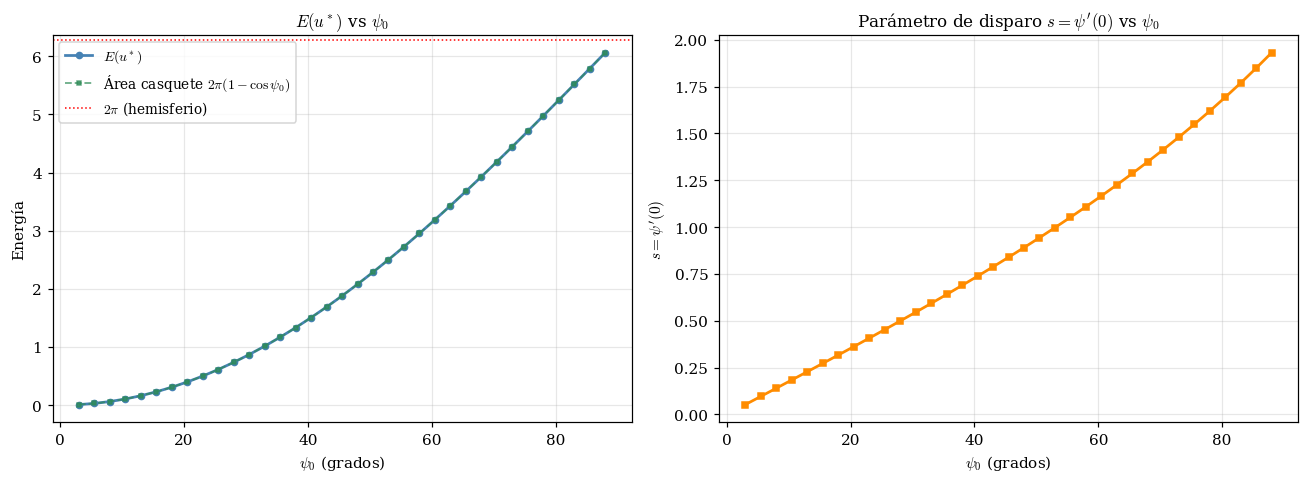


Comparación E(u*) vs área del casquete:
  psi0       E(u*)        Área    Diferencia
    20°     0.37892     0.37892      -0.00000
    40°     1.46998     1.46999      -0.00000
    60°     3.14159     3.14159      -0.00000
    75°     4.65697     4.65698      -0.00001


In [17]:
angulos_curva = np.linspace(3, 88, 35)
energias, s_vals = [], []

for deg in angulos_curva:
    _, _, _, s, E = solve_membrane(np.radians(deg))
    energias.append(E)
    s_vals.append(s)

energias = np.array(energias)
s_vals   = np.array(s_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Energía ---
ax1.plot(angulos_curva, energias, 'o-',
         color='steelblue', ms=4, lw=1.8, label=r'$E(u^*)$')
ax1.plot(angulos_curva, 2*np.pi*(1 - np.cos(np.radians(angulos_curva))),
         's--', color='seagreen', ms=3, lw=1.2, alpha=0.7,
         label=r'Área casquete $2\pi(1-\cos\psi_0)$')
ax1.axhline(2*np.pi, color='red', ls=':', lw=1,
            label=r'$2\pi$ (hemisferio)')
ax1.set_xlabel(r'$\psi_0$ (grados)')
ax1.set_ylabel(r'Energía')
ax1.set_title(r'$E(u^*)$ vs $\psi_0$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Parámetro de disparo ---
ax2.plot(angulos_curva, s_vals, 's-',
         color='darkorange', ms=4, lw=1.8)
ax2.set_xlabel(r'$\psi_0$ (grados)')
ax2.set_ylabel(r"$s = \psi'(0)$")
ax2.set_title(r"Parámetro de disparo $s = \psi'(0)$ vs $\psi_0$")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nComparación E(u*) vs área del casquete:")
print(f"{'psi0':>6}  {'E(u*)':>10}  {'Área':>10}  {'Diferencia':>12}")
for deg in [20, 40, 60, 75]:
    psi0 = np.radians(deg)
    _, _, _, _, E = solve_membrane(psi0)
    area = 2*np.pi*(1 - np.cos(psi0))
    print(f"{deg:>6}°  {E:>10.5f}  {area:>10.5f}  {E-area:>12.5f}")

## 8. Análisis detallado para un ángulo elegido

Cambia `psi0_deg` para explorar distintos ángulos de anclaje.  
Se muestran: el perfil $\psi(r)$, su derivada $\psi'(r)$,
y el casquete esférico 3D.

psi_0      = 55° = 0.95993 rad
s = psi'(0) = 1.04113391
E(u*)       = 2.67929481
E / 2pi     = 0.42642301
|psi(1)-psi0| = 2.22e-16


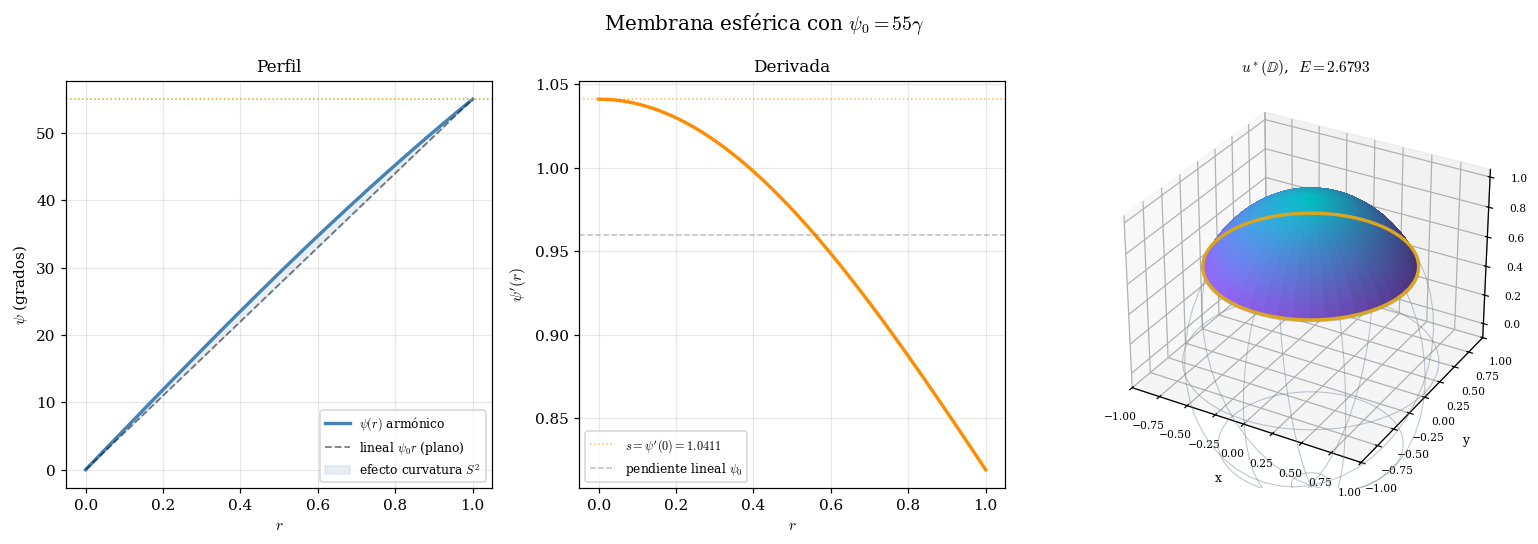

In [18]:
# Parámetro a explorar
psi0_deg = 55    # <-- cambiar aquí entre 5 y 88 grados


psi0 = np.radians(psi0_deg)
r, psi, dpsi, s, E = solve_membrane(psi0, N=3000)

print(f"psi_0      = {psi0_deg}° = {psi0:.5f} rad")
print(f"s = psi'(0) = {s:.8f}")
print(f"E(u*)       = {E:.8f}")
print(f"E / 2pi     = {E/(2*np.pi):.8f}")
print(f"|psi(1)-psi0| = {abs(psi[-1]-psi0):.2e}")

fig = plt.figure(figsize=(14, 5))
fig.suptitle(fr'Membrana esférica con $\psi_0 = {psi0_deg}°$', fontsize=13)

# -- Perfil psi(r) --
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(r, np.degrees(psi), color='steelblue', lw=2.2,
         label=r'$\psi(r)$ armónico')
ax1.plot([0,1], [0, psi0_deg], 'k--', lw=1.2, alpha=0.5,
         label=r'lineal $\psi_0 r$ (plano)')
ax1.axhline(psi0_deg, color='goldenrod', ls=':', lw=1)
ax1.fill_between(r, np.degrees(psi), r*psi0_deg,
                 alpha=0.12, color='steelblue',
                 label='efecto curvatura $S^2$')
ax1.set_xlabel(r'$r$'); ax1.set_ylabel(r'$\psi$ (grados)')
ax1.set_title('Perfil'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# -- Derivada psi'(r) --
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(r, dpsi, color='darkorange', lw=2.2)
ax2.axhline(s, color='darkorange', ls=':', lw=1, alpha=0.6,
            label=fr"$s = \psi'(0) = {s:.4f}$")
ax2.axhline(psi0_deg * np.pi/180, color='gray', ls='--', lw=1, alpha=0.5,
            label=r'pendiente lineal $\psi_0$')
ax2.set_xlabel(r'$r$'); ax2.set_ylabel(r"$\psi'(r)$")
ax2.set_title("Derivada"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# -- Casquete 3D --
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
dibujar_casquete(ax3, r, psi, psi0_deg,
                 titulo=fr'$u^*(\mathbb{{D}})$,  $E={E:.4f}$')

plt.tight_layout()
plt.show()

## 9. Convergencia del método de bisección

Graficamos el error $|\Phi(s_n)| = |\psi(1; s_n) - \psi_0|$
en cada iteración de la bisección, para verificar la convergencia geométrica
con tasa $2^{-n}$.

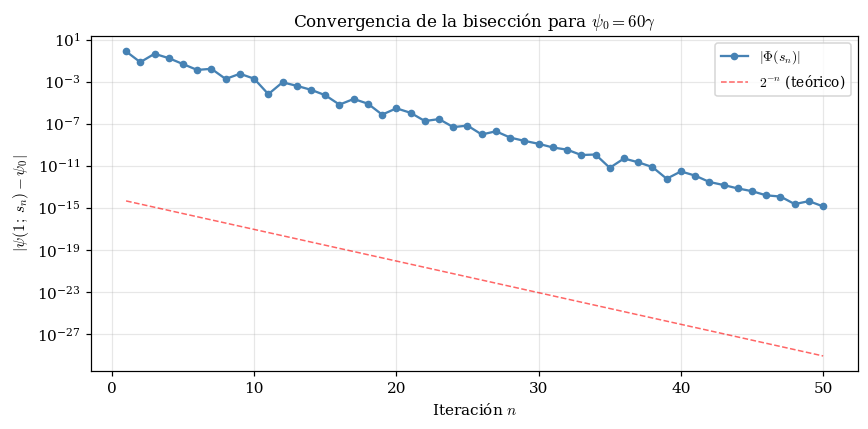

Error tras 50 iteraciones: 1.33e-15


In [19]:
psi0_conv = np.radians(60)
eps_conv  = 1e-3
N_conv    = 500

def shoot_simple(s):
    sol = solve_ivp(ode_system, (eps_conv, 1.0), [s*eps_conv, s],
                    t_eval=[1.0], rtol=1e-11, atol=1e-13)
    return sol.y[0, -1]

s_lo, s_hi = 0.0, 5.0
while shoot_simple(s_hi) < psi0_conv:
    s_hi *= 2
L0 = s_hi - s_lo  # guardar antes de iterar

errores = []
for _ in range(50):
    s_mid = 0.5*(s_lo + s_hi)
    val = shoot_simple(s_mid)
    errores.append(abs(val - psi0_conv))
    if val < psi0_conv:
        s_lo = s_mid
    else:
        s_hi = s_mid

n_arr = np.arange(1, len(errores)+1)
ax.semilogy(n_arr, L0 * 2.0**(-n_arr), 'r--', lw=1, alpha=0.7, label='cota teórica')

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(errores)+1), errores, 'o-',
            color='steelblue', ms=4, lw=1.5, label=r'$|\Phi(s_n)|$')

# Línea teórica 2^{-n}
n_arr = np.arange(1, len(errores)+1)
# Corrección para evitar error de potencias negativas con enteros
ax.semilogy(n_arr, (s_hi - s_lo) * 2.0**(-n_arr + 1), 'r--',
            lw=1, alpha=0.6, label=r'$2^{-n}$ (teórico)')

ax.set_xlabel('Iteración $n$')
ax.set_ylabel(r'$|\psi(1\,;\,s_n) - \psi_0|$')
ax.set_title(fr'Convergencia de la bisección para $\psi_0 = 60°$')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Error tras 50 iteraciones: {errores[-1]:.2e}")

## 10. Resumen y conexión con la teoría


| Objeto matemático | Rol en Struwe | Implementación |
|---|---|---|
| $E(u) = \int g_{ij}(u)\nabla u^i\nabla u^j$ | Funcional a minimizar | `solve_membrane` calcula $E$ por la regla del trapecio |
| $\mathcal{M} \subset H^{1,2}(\mathbb{D}; S^2)$ | Clase admisible | La malla de valores $\psi(r_k)$ con $\psi(r_k) \in [0,\pi]$ |
| Rellich–Kondrachov | Compacidad $H^1 \to L^2$ | La bisección acota $\{s_n\}$, los perfiles quedan en $S^2$ |
| s.c.i. débil de $E$ | Clave de existencia | $E$ es cuadrático en $\psi'$: cualquier límite débil lo minimiza |
| Singularidad en $r=0$ | Regularidad del minimizante | Tratada con la condición $\psi''(0) = 0$ (L'Hôpital) |
| Parámetro $s = \psi'(0)$ | Ecuación de Euler–Lagrange | Raíz de la función de disparo $\Phi(s)$ |

### Comentario final

El minimizante $u^*$ de Struwe **existe y es único** para cada $\psi_0 \in (0, \pi/2)$
porque el espacio objetivo $S^2$ es compacto y la clase $\mathcal{M}$ es
convexamente cerrada en $H^{1,2}$.

La ODE es la **ecuación de aplicaciones armónicas con simetría axial**:
su solución $\psi(r)$ describe una aplicación $u^*: \mathbb{D} \to S^2$
cuya imagen es un casquete esférico que minimiza la energía elástica.

El efecto de la curvatura de $S^2$ (término $\sin\psi\cos\psi / r^2$)
hace que el perfil real sea **mayor** que el lineal trivial:
la membrana se «abre» más rápido porque la esfera se ensancha al alejarse del polo.